#### Query: (hand or gripper) and (manipulation or grasping or grip or skill)  
#### Years: 2019-2025 (6 Years)
#### Citation: 1+
#### Source: Google Scholar

In [15]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_crawler_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "GS_crawler",
        cwd / "crawlers" / "GS_crawler",
        cwd / "JIRS-HandsSurvey" / "crawlers" / "GS_crawler",
    ]
    for candidate in candidates:
        if (candidate / "gs_crawler.py").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the GS_crawler directory.")


def open_json_file(file_path):
    with Path(file_path).open(encoding="utf-8") as file:
        return json.load(file)


def page_number(path):
    return int(path.stem.rsplit("_", 1)[-1])


CRAWLER_DIR = find_crawler_dir()
GS_DATA_DIR = CRAWLER_DIR / "data"
GS_ERROR_DIR = CRAWLER_DIR / "errors"
IEEE_DATA_DIR = CRAWLER_DIR.parent / "IEEE-Xplore-API_p3" / "data"
OUTPUT_PATH = CRAWLER_DIR / "articles_gs_ieee_new_filtered.csv"

count_all = 0
count_after_duplicates = 0
count_after_arxiv_ieee_remove = 0
all_articles_gs = []
citations_gs = []
years_gs = []
titles_gs = []
source_gs = []
publisher_gs = []
seen_titles_gs = set()

files_list = sorted(GS_DATA_DIR.glob("data_*.json"), key=page_number)
if not files_list:
    raise FileNotFoundError(f"No successful Scholar pages found in {GS_DATA_DIR}")

for file_path in files_list:
    data_gs = open_json_file(file_path)
    for article in data_gs.get("organic_results", []):
        cited_by = (article.get("inline_links") or {}).get("cited_by")
        title_gs = str(article.get("title", "")).strip()
        if not title_gs or not isinstance(cited_by, dict):
            continue

        count_all += 1
        title_key = " ".join(title_gs.lower().split())
        if title_key in seen_titles_gs:
            continue
        seen_titles_gs.add(title_key)
        count_after_duplicates += 1

        summary = str((article.get("publication_info") or {}).get("summary", ""))
        summary_parts = [part.strip() for part in summary.split(" - ")]
        publisher = summary_parts[-1] if len(summary_parts) > 1 else ""
        if "arxiv" in publisher.lower() or "ieee" in publisher.lower():
            continue

        source_and_year = summary_parts[-2] if len(summary_parts) > 1 else summary
        year_matches = re.findall(r"\b(?:19|20)\d{2}\b", summary)
        source = re.sub(r"[, ]*(?:19|20)\d{2}\s*$", "", source_and_year).strip()

        count_after_arxiv_ieee_remove += 1
        all_articles_gs.append(article)
        citations_gs.append(cited_by.get("total", 0))
        years_gs.append(int(year_matches[-1]) if year_matches else 0)
        source_gs.append(source)
        publisher_gs.append(publisher)
        titles_gs.append(title_gs)

error_files = sorted(GS_ERROR_DIR.glob("data_*.json"), key=page_number)
print(f"Loaded {len(files_list)} successful Scholar pages from {GS_DATA_DIR}")
print(f"Crawler error pages currently stored: {len(error_files)}")

Loaded 6 successful Scholar pages from /Users/adonaisray.maclang/Desktop/robotics-survey/JIRS-HandsSurvey/crawlers/GS_crawler/data
Crawler error pages currently stored: 44


In [16]:
count_all

115

In [17]:
count_after_duplicates

104

In [18]:
count_after_arxiv_ieee_remove

60

In [19]:
print("Overall Number of Articles: ",len(all_articles_gs))

Overall Number of Articles:  60


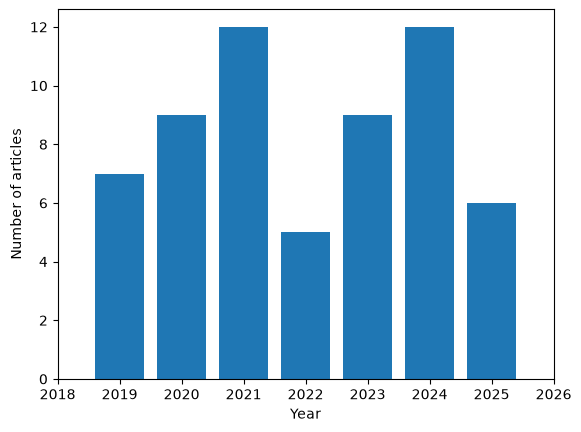

In [20]:
plt.bar(*np.unique(years_gs, return_counts=True), )
# set x-axis label
plt.xlabel('Year')
# set y-axis label
plt.ylabel('Number of articles')
plt.xlim(2018, 2026)
plt.show()

## Include IEEE Papers

In [21]:
def extract_ieee_terms(article):
    index_terms = article.get("index_terms")
    if not isinstance(index_terms, dict):
        return []

    terms = []
    for term_group in index_terms.values():
        if not isinstance(term_group, dict):
            continue
        terms.extend(
            str(term).strip().lower()
            for term in term_group.get("terms", [])
            if str(term).strip()
        )
    return sorted(set(terms))


list_files = sorted(IEEE_DATA_DIR.glob("data_*.json"), key=page_number)
if not list_files:
    raise FileNotFoundError(f"No IEEE result pages found in {IEEE_DATA_DIR}")

all_articles_ieee_raw = []
for file_path in list_files:
    data_ieee = open_json_file(file_path)
    all_articles_ieee_raw.extend(data_ieee.get("articles", []))

# Deduplicate overlapping API pages using IEEE's stable article number.
articles_ieee_by_id = {}
for article in all_articles_ieee_raw:
    identifier = article.get("article_number") or article.get("title")
    if identifier:
        articles_ieee_by_id.setdefault(str(identifier), article)
all_articles_ieee = list(articles_ieee_by_id.values())

keywords_0 = ["hand", "gripper"]
keywords_1 = ["manipulation", "grasping", "grip", "skill"]
keywords_used = []
terms_used = []
articles_filtered_ieee = []
articles_filtered_titles_ieee = []
missing_index_terms = 0

for article in all_articles_ieee:
    try:
        citations = int(article.get("citing_paper_count", 0) or 0)
    except (TypeError, ValueError):
        citations = 0
    if citations <= 0:
        continue

    all_terms = extract_ieee_terms(article)
    if not all_terms:
        missing_index_terms += 1
        continue

    matched_0 = [word for word in keywords_0 if any(word in term for term in all_terms)]
    matched_1 = [word for word in keywords_1 if any(word in term for term in all_terms)]
    if matched_0 and matched_1:
        articles_filtered_ieee.append(article)
        articles_filtered_titles_ieee.append(str(article.get("title", "")))
        keywords_used.extend(matched_0 + matched_1)
        terms_used.extend(all_terms)

terms_used = sorted(set(terms_used))
print(f"Loaded {len(list_files)} IEEE pages from {IEEE_DATA_DIR}")
print(f"Raw IEEE rows: {len(all_articles_ieee_raw)}")
print(f"Unique IEEE articles: {len(all_articles_ieee)}")
print(f"Skipped {missing_index_terms} cited articles without usable index terms")

Loaded 33 IEEE pages from /Users/adonaisray.maclang/Desktop/robotics-survey/JIRS-HandsSurvey/crawlers/IEEE-Xplore-API_p3/data
Raw IEEE rows: 6413
Unique IEEE articles: 6413
Skipped 1807 cited articles without usable index terms


In [ ]:
len(all_articles_ieee)

6413

In [ ]:
len(articles_filtered_ieee)

2070

In [ ]:
def normalize_title(title):
    return " ".join(re.sub(r"[^a-z0-9]+", " ", str(title).lower()).split())


# Match normalized titles so IEEE records already present in Scholar are not exported twice.
gs_articles_by_title = {
    normalize_title(article.get("title", "")): article
    for article in all_articles_gs
    if article.get("title")
}
article_found_ieee = []
article_not_found_ieee = []

for article_ieee in articles_filtered_ieee:
    title_key = normalize_title(article_ieee.get("title", ""))
    matching_gs_article = gs_articles_by_title.get(title_key)
    if matching_gs_article is not None:
        abstract = article_ieee.get("abstract")
        if abstract:
            matching_gs_article["snippet"] = abstract
        article_found_ieee.append(article_ieee)
    else:
        article_not_found_ieee.append(article_ieee)

print(f"IEEE records matched to Scholar: {len(article_found_ieee)}")
print(f"Unique IEEE records to add: {len(article_not_found_ieee)}")

IEEE records matched to Scholar: 0
Unique IEEE records to add: 2070


In [ ]:
len(article_not_found_ieee) + len(all_articles_gs)

2130

In [ ]:
import csv

header = [
    "Title", "Citations", "Year", "Source", "Publisher",
    "Snippet", "URL", "Keywords", "Name", "Relevant (Yes/No)",
]

with OUTPUT_PATH.open("w", encoding="utf-8", newline="") as file:
    writer = csv.writer(file, delimiter=";", quotechar='"', quoting=csv.QUOTE_MINIMAL)
    writer.writerow(header)

    for index, article in enumerate(all_articles_gs):
        writer.writerow([
            article.get("title", ""),
            citations_gs[index],
            years_gs[index],
            source_gs[index],
            publisher_gs[index],
            article.get("snippet", ""),
            article.get("link", ""),
            "", "", "",
        ])

    # Export only IEEE records that were not matched to a Scholar title.
    for article in article_not_found_ieee:
        writer.writerow([
            article.get("title", ""),
            article.get("citing_paper_count", 0),
            article.get("publication_year", ""),
            article.get("publication_title", ""),
            "IEEE",
            article.get("abstract", ""),
            article.get("pdf_url") or article.get("html_url", ""),
            " | ".join(extract_ieee_terms(article)),
            "",
            "Yes",
        ])

print(f"Wrote {len(all_articles_gs) + len(article_not_found_ieee)} records to {OUTPUT_PATH}")

Wrote 2130 records to /Users/adonaisray.maclang/Desktop/robotics-survey/JIRS-HandsSurvey/crawlers/GS_crawler/articles_gs_ieee_new_filtered.csv
